In [1]:
import torchvision as torchvision
!kaggle competitions download -c digit-recognizer


  0%|          | 0.00/15.3M [00:00<?, ?B/s]
  7%|6         | 1.00M/15.3M [00:00<00:05, 2.98MB/s]
 13%|#3        | 2.00M/15.3M [00:00<00:04, 3.22MB/s]
 20%|#9        | 3.00M/15.3M [00:00<00:03, 3.26MB/s]
 26%|##6       | 4.00M/15.3M [00:01<00:03, 3.36MB/s]
 33%|###2      | 5.00M/15.3M [00:01<00:03, 3.43MB/s]
 39%|###9      | 6.00M/15.3M [00:01<00:03, 3.25MB/s]
 46%|####5     | 7.00M/15.3M [00:02<00:02, 3.27MB/s]
 52%|#####2    | 8.00M/15.3M [00:02<00:02, 3.25MB/s]
 59%|#####8    | 9.00M/15.3M [00:02<00:02, 3.21MB/s]
 65%|######5   | 10.0M/15.3M [00:03<00:01, 3.14MB/s]
 72%|#######1  | 11.0M/15.3M [00:03<00:01, 3.20MB/s]
 78%|#######8  | 12.0M/15.3M [00:03<00:01, 3.24MB/s]
 85%|########4 | 13.0M/15.3M [00:04<00:00, 3.20MB/s]
 91%|#########1| 14.0M/15.3M [00:04<00:00, 3.10MB/s]
 98%|#########7| 15.0M/15.3M [00:04<00:00, 3.10MB/s]
100%|##########| 15.3M/15.3M [00:05<00:00, 3.20MB/s]


In [2]:
import zipfile

with zipfile.ZipFile("digit-recognizer.zip", 'r') as zip_ref:
    zip_ref.extractall("data/")

In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [4]:
train = pd.read_csv('data/train.csv')
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
subtrain, subtest = train_test_split(train, test_size=0.2)

In [6]:
subtrain_labels_tensor, subtrain_tensor = torch.tensor(subtrain["label"].values), torch.tensor(
    subtrain.drop(columns="label").values)
subtest_labels_tensor, subtest_tensor = torch.tensor(subtest["label"].values), torch.tensor(
    subtest.drop(columns="label").values)

In [7]:
test = pd.read_csv('data/test.csv')
test_tensor = torch.tensor(test.values)

In [8]:
subtrain_tensor.shape


torch.Size([33600, 784])

In [9]:
subtrain_tensor = subtrain_tensor.reshape(-1, 1, 28, 28) / 255

In [10]:
subtest_tensor = subtest_tensor.reshape(-1, 1, 28, 28) / 255

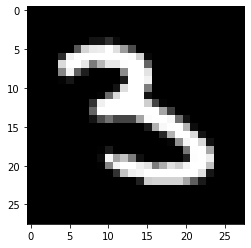

In [11]:
plt.imshow(subtrain_tensor.data[20].squeeze(), cmap='Greys_r')

In [12]:
dataset = TensorDataset(subtrain_tensor, subtrain_labels_tensor)
subtrain_loader = DataLoader(dataset, 16, shuffle=True)

dataset = TensorDataset(subtest_tensor, subtest_labels_tensor)
subtest_loader = DataLoader(dataset, 16, shuffle=True)

In [13]:

class Net(nn.Module):
    def __init__(self, l1, l2, first_conv_size, conv_kernel_size):
        super().__init__()

        self.feature_extractor = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=first_conv_size,
                                                         kernel_size=(conv_kernel_size, conv_kernel_size),
                                                         padding='same'),
                                               nn.ReLU(),
                                               nn.MaxPool2d(kernel_size=2, stride=2),
                                               nn.Conv2d(in_channels=first_conv_size, out_channels=2 * first_conv_size,
                                                         kernel_size=(conv_kernel_size, conv_kernel_size),
                                                         padding='same'),
                                               nn.ReLU(),
                                               nn.Flatten()
                                               )
        n_channels = self.feature_extractor(torch.empty(1, 1, 28, 28)).size(-1)
        self.classifier = nn.Sequential(nn.Linear(n_channels, l1),
                                        nn.ReLU(),
                                        nn.Linear(l1, l2),
                                        nn.ReLU(),
                                        nn.Linear(l2, 10))

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x


In [14]:
def training(train_loader, logging_interval):
    num_epochs = 5
    loss_fn = torch.nn.CrossEntropyLoss()
    net = Net(256, 128, 32, 3)
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

    losses = []
    for epoch in range(num_epochs):
        print(f'Starting epoch {epoch + 1}')

        current_loss = 0.0

        for i, data in enumerate(train_loader, 0):
            inputs, targets = data
            outputs = net(inputs)
            optimizer.zero_grad()
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            current_loss += loss.item()
            if i % logging_interval == logging_interval-1:
                print('Loss after mini-batch %5d: %.3f' %
                      (i + 1, current_loss / logging_interval))
                losses.append(current_loss / logging_interval)
                current_loss = 0.0

    print('Training process has finished.')
    return net

In [15]:
model = training(subtrain_loader, 300)

Starting epoch 1
Loss after mini-batch   300: 0.525
Loss after mini-batch   600: 0.169
Loss after mini-batch   900: 0.139
Loss after mini-batch  1200: 0.108
Loss after mini-batch  1500: 0.104
Loss after mini-batch  1800: 0.085
Loss after mini-batch  2100: 0.081
Starting epoch 2
Loss after mini-batch   300: 0.052
Loss after mini-batch   600: 0.062
Loss after mini-batch   900: 0.052
Loss after mini-batch  1200: 0.061
Loss after mini-batch  1500: 0.041
Loss after mini-batch  1800: 0.054
Loss after mini-batch  2100: 0.055
Starting epoch 3
Loss after mini-batch   300: 0.034
Loss after mini-batch   600: 0.035
Loss after mini-batch   900: 0.031
Loss after mini-batch  1200: 0.033
Loss after mini-batch  1500: 0.039
Loss after mini-batch  1800: 0.036
Loss after mini-batch  2100: 0.030
Starting epoch 4
Loss after mini-batch   300: 0.023
Loss after mini-batch   600: 0.026
Loss after mini-batch   900: 0.025
Loss after mini-batch  1200: 0.021
Loss after mini-batch  1500: 0.030
Loss after mini-batch 

In [16]:
def testing(test_loader, model):
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))

    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            y_pred = model(images)
            _, predicted = torch.max(y_pred, 1)
            c = (predicted == labels).squeeze()
            for i in range(4):
                label = labels[i]
                class_correct[label] += c[i]
                class_total[label] += 1

    for i in range(10):
        print(f'Accuracy of {i} : {100 * class_correct[i] / class_total[i]} %')
    print(f'Average accuracy: {round(float(100 * sum(class_correct) / sum(class_total)))} %')

In [17]:
testing(subtest_loader, model)

Accuracy of 0 : 99.08676147460938 %
Accuracy of 1 : 98.1651382446289 %
Accuracy of 2 : 100.0 %
Accuracy of 3 : 97.16981506347656 %
Accuracy of 4 : 99.44444274902344 %
Accuracy of 5 : 99.46808624267578 %
Accuracy of 6 : 99.53704071044922 %
Accuracy of 7 : 97.59615325927734 %
Accuracy of 8 : 99.13793182373047 %
Accuracy of 9 : 99.50980377197266 %
Average accuracy: 99 %


In [18]:
train_labels_tensor, train_tensor = torch.tensor(subtrain["label"].values), \
                                          torch.tensor(subtrain.drop(columns="label").values)
train_tensor = train_tensor.reshape(-1, 1, 28, 28) / 255
dataset = TensorDataset(train_tensor, train_labels_tensor)
train_loader = DataLoader(dataset, 16, shuffle=True)

In [19]:
model = training(train_loader, 375)

Starting epoch 1
Loss after mini-batch   375: 0.471
Loss after mini-batch   750: 0.145
Loss after mini-batch  1125: 0.120
Loss after mini-batch  1500: 0.095
Loss after mini-batch  1875: 0.089
Starting epoch 2
Loss after mini-batch   375: 0.062
Loss after mini-batch   750: 0.052
Loss after mini-batch  1125: 0.054
Loss after mini-batch  1500: 0.050
Loss after mini-batch  1875: 0.059
Starting epoch 3
Loss after mini-batch   375: 0.028
Loss after mini-batch   750: 0.028
Loss after mini-batch  1125: 0.035
Loss after mini-batch  1500: 0.037
Loss after mini-batch  1875: 0.036
Starting epoch 4
Loss after mini-batch   375: 0.022
Loss after mini-batch   750: 0.031
Loss after mini-batch  1125: 0.025
Loss after mini-batch  1500: 0.020
Loss after mini-batch  1875: 0.022
Starting epoch 5
Loss after mini-batch   375: 0.014
Loss after mini-batch   750: 0.028
Loss after mini-batch  1125: 0.018
Loss after mini-batch  1500: 0.027
Loss after mini-batch  1875: 0.015
Training process has finished.


In [20]:
test_tensor = test_tensor.reshape(-1, 1, 28, 28) / 255
test_loader = DataLoader(test_tensor, len(test_tensor), shuffle=False)

In [21]:
with torch.no_grad():
    for data in test_loader:
        images = data
        y_pred = model(images)
        _, predicted = torch.max(y_pred, 1)
    print(predicted)

tensor([2, 0, 9,  ..., 3, 9, 2])


In [22]:
submission = pd.DataFrame({'ImageId': list(range(1,28001)), 'Label': predicted.numpy()})
submission.to_csv("submission.csv", index=False)


In [23]:
!kaggle competitions submit -c digit-recognizer -f submission.csv -m "Message"

Successfully submitted to Digit Recognizer



  0%|          | 0.00/235k [00:00<?, ?B/s]
 34%|###4      | 80.0k/235k [00:00<00:00, 729kB/s]
 85%|########5 | 200k/235k [00:00<00:00, 1.01MB/s]
100%|##########| 235k/235k [00:02<00:00, 98.2kB/s]
